# Week 3: Statistical Analysis and Hypothesis Testing

## Superstore Sales Dataset

### Objective
This week focuses on applying statistical analysis and hypothesis testing
to validate a business-related hypothesis using Python.

The analysis investigates whether discounting is associated with a significant
difference in profitability.

### Tools Used
- Python
- Pandas
- NumPy
- SciPy
- Matplotlib
- Seaborn

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import ttest_ind

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [13]:
# Load the Superstore dataset

df = pd.read_excel("../dataset/superstore_sales.xls")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 10194
Columns: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [14]:
# Create two independent groups

no_discount = df.loc[df["Discount"] == 0, "Profit"].dropna()
discounted = df.loc[df["Discount"] > 0, "Profit"].dropna()

print("No Discount Group")
print("Number of observations:", len(no_discount))
print("Mean Profit:", no_discount.mean())

print("\nDiscounted Group")
print("Number of observations:", len(discounted))
print("Mean Profit:", discounted.mean())


No Discount Group
Number of observations: 4925
Mean Profit: 66.33879943147207

Discounted Group
Number of observations: 5269
Mean Profit: -6.532885291326637


In [15]:
# Welch's Independent Two-Sample t-test

t_stat, p_value = ttest_ind(
    no_discount,
    discounted,
    equal_var=False
)

print("Welch's Independent Two-Sample t-test")
print("=" * 50)
print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

print("\nSignificance Level (alpha):", alpha)

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis (H₀)")
else:
    print("Decision: Fail to Reject the Null Hypothesis (H₀)")

Welch's Independent Two-Sample t-test
t-statistic: 15.89407873219623
p-value: 3.7270202073140507e-56

Significance Level (alpha): 0.05
Decision: Reject the Null Hypothesis (H₀)


In [16]:
# 95% Confidence Interval for the Difference in Mean Profit

mean_difference = no_discount.mean() - discounted.mean()

# Sample sizes
n1 = len(no_discount)
n2 = len(discounted)

# Sample variances
var1 = no_discount.var(ddof=1)
var2 = discounted.var(ddof=1)

# Standard error of the difference
standard_error = np.sqrt((var1 / n1) + (var2 / n2))

# Welch-Satterthwaite degrees of freedom
degrees_freedom = (
    ((var1 / n1) + (var2 / n2)) ** 2
    /
    (((var1 / n1) ** 2 / (n1 - 1)) +
     ((var2 / n2) ** 2 / (n2 - 1)))
)

# Critical t-value for 95% CI
confidence_level = 0.95
alpha = 1 - confidence_level

t_critical = stats.t.ppf(1 - alpha / 2, degrees_freedom)

# Confidence interval
margin_of_error = t_critical * standard_error

ci_lower = mean_difference - margin_of_error
ci_upper = mean_difference + margin_of_error

print("95% Confidence Interval")
print("=" * 50)
print("Mean Difference (No Discount - Discounted):", mean_difference)
print("Degrees of Freedom:", degrees_freedom)
print("Standard Error:", standard_error)
print("95% CI Lower Bound:", ci_lower)
print("95% CI Upper Bound:", ci_upper)


95% Confidence Interval
Mean Difference (No Discount - Discounted): 72.8716847227987
Degrees of Freedom: 9419.01708034799
Standard Error: 4.584832247948061
95% CI Lower Bound: 63.88442376110926
95% CI Upper Bound: 81.85894568448815


## 2. Hypothesis Test Results and Interpretation

### Statistical Test
Welch's Independent Two-Sample t-test was used to compare the mean profit
of orders with no discount and orders that received a discount.

### Results

- No Discount Mean Profit: $66.34
- Discounted Mean Profit: -$6.53
- Mean Difference: $72.87
- t-statistic: 15.8941
- p-value: 3.7270 × 10⁻⁵⁶
- Significance Level (α): 0.05
- 95% Confidence Interval: [$63.88, $81.86]

### Decision

Since the p-value is much smaller than 0.05, the Null Hypothesis (H₀)
is rejected.

### Interpretation

The results provide strong statistical evidence that the mean profit differs
between orders with no discount and orders that received a discount. The
estimated mean difference is approximately $72.87, with a 95% confidence
interval from $63.88 to $81.86.

Because the confidence interval does not contain zero, it provides additional
evidence of a statistically significant difference between the two groups.

This analysis identifies a statistically significant association between
discount status and observed profit differences. It does not by itself prove
that discounts causally caused the difference in profit.

## 3. Profit Distribution by Discount Status

The distribution of profit is compared between orders with no discount
and orders that received a discount. This visualization helps identify
differences in central tendency and spread between the two groups.

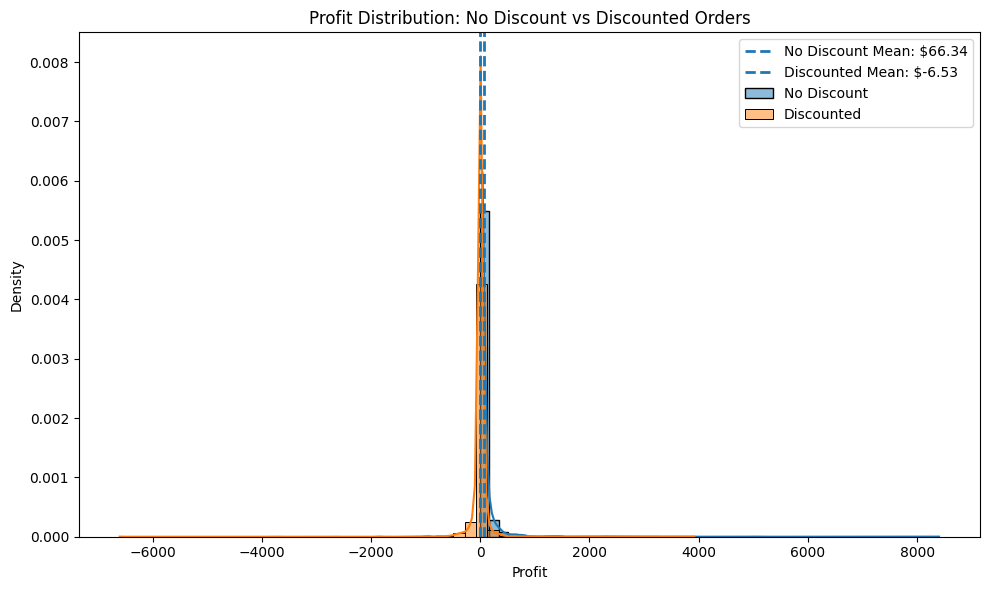

In [17]:
# Profit Distribution by Discount Status

plt.figure(figsize=(10, 6))

sns.histplot(
    no_discount,
    bins=50,
    kde=True,
    stat="density",
    label="No Discount",
    alpha=0.5
)

sns.histplot(
    discounted,
    bins=50,
    kde=True,
    stat="density",
    label="Discounted",
    alpha=0.5
)

plt.axvline(
    no_discount.mean(),
    linestyle="--",
    linewidth=2,
    label=f"No Discount Mean: ${no_discount.mean():.2f}"
)

plt.axvline(
    discounted.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Discounted Mean: ${discounted.mean():.2f}"
)

plt.title("Profit Distribution: No Discount vs Discounted Orders")
plt.xlabel("Profit")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
# Compare sample variances

print("Variance Comparison")
print("=" * 50)

print("No Discount Variance:", no_discount.var())
print("Discounted Variance:", discounted.var())

print("\nNo Discount Standard Deviation:", no_discount.std())
print("Discounted Standard Deviation:", discounted.std())

Variance Comparison
No Discount Variance: 64836.65024359342
Discounted Variance: 41392.65628358808

No Discount Standard Deviation: 254.63041892828403
Discounted Standard Deviation: 203.45185249485462


## 4. Profit Comparison Using Box Plot

A box plot is used to compare the distribution, median, spread, and
potential outliers of profit between the two discount groups.

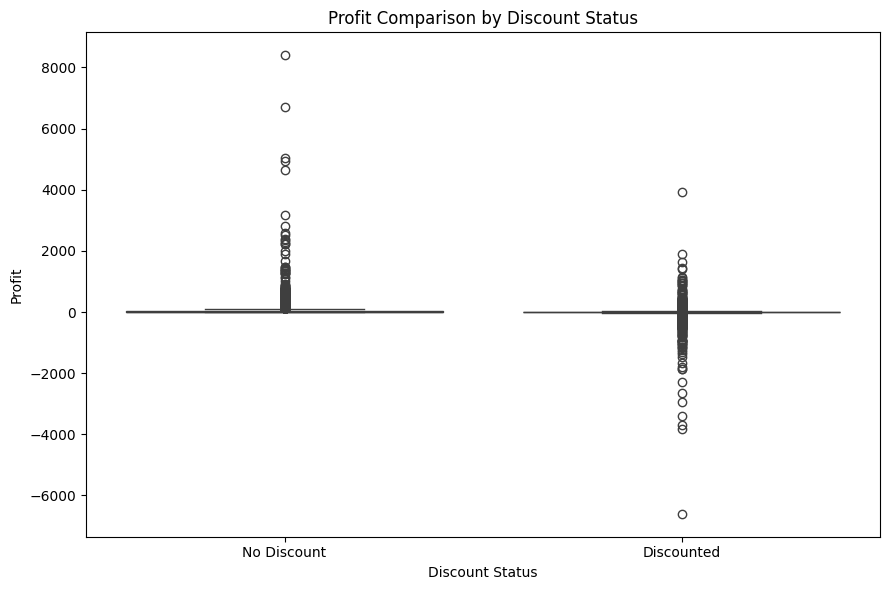

In [19]:
# Prepare data for box plot

plot_data = pd.DataFrame({
    "Profit": pd.concat([no_discount, discounted], ignore_index=True),
    "Discount Status": (
        ["No Discount"] * len(no_discount)
        + ["Discounted"] * len(discounted)
    )
})

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=plot_data,
    x="Discount Status",
    y="Profit"
)

plt.title("Profit Comparison by Discount Status")
plt.xlabel("Discount Status")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

## 5. Mean Profit Comparison

The mean profit of the two groups is compared directly to make the
statistical difference easier to communicate.

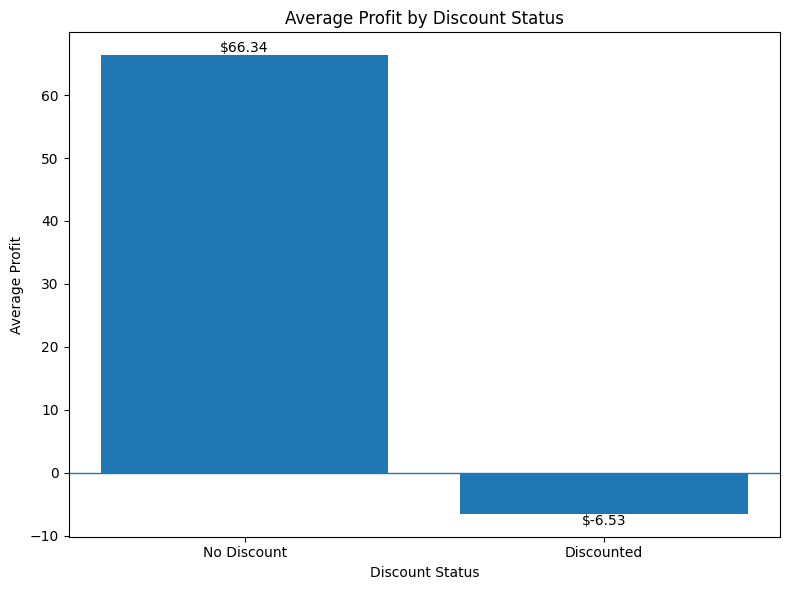

In [20]:
# Mean Profit Comparison

group_means = pd.Series({
    "No Discount": no_discount.mean(),
    "Discounted": discounted.mean()
})

plt.figure(figsize=(8, 6))

bars = plt.bar(
    group_means.index,
    group_means.values
)

plt.axhline(0, linewidth=1)

plt.title("Average Profit by Discount Status")
plt.xlabel("Discount Status")
plt.ylabel("Average Profit")

for bar, value in zip(bars, group_means.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"${value:.2f}",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

plt.tight_layout()
plt.show()

## 6. Statistical Assumption Check

The analysis uses Welch's independent two-sample t-test. Welch's test is
appropriate when comparing two independent groups without assuming that
their population variances are equal.

The observations represent separate orders, and the two groups are defined
by discount status. Because the dataset contains a large number of
observations, the t-test provides a useful comparison of the group means.

The analysis focuses on the difference in mean profit and reports both the
p-value and a 95% confidence interval.

## 7. Final Statistical Conclusion

The analysis compared the profitability of orders with no discount against
orders that received a discount.

The no-discount group contained 4,925 observations with a mean profit of
$66.34, while the discounted group contained 5,269 observations with a
mean profit of approximately -$6.53.

Welch's independent two-sample t-test produced a t-statistic of 15.8941 and
a p-value of approximately 3.73 × 10⁻⁵⁶. Since the p-value is far below the
significance level of 0.05, the null hypothesis is rejected.

The estimated difference in mean profit was $72.87, with a 95% confidence
interval from $63.88 to $81.86. Because the interval does not include zero,
the confidence interval also supports the conclusion that the group means
are statistically different.

Therefore, the analysis provides strong evidence of a statistically
significant difference in observed profit between discounted and
non-discounted orders.

However, statistical significance does not establish causation. Other
factors such as product category, quantity, region, customer segment, and
order characteristics may also contribute to differences in profit.

## 8. Business Insights

1. Orders without discounts had a substantially higher average profit than
   discounted orders in the analyzed dataset.

2. The statistical test indicates that the difference in mean profit is
   statistically significant.

3. The confidence interval suggests that the estimated mean-profit
   difference is between approximately $63.88 and $81.86.

4. Discount policies should therefore be examined carefully from a
   profitability perspective.

5. Further analysis should investigate whether the observed relationship
   differs across product categories, regions, and customer segments.

6. The results should be interpreted as an observed statistical association,
   not as proof that discounts alone caused lower profits.